Question 1: Which books and categories were most popular by decade, and how did popularity metrics evolve over time?

In [1]:
# Setup and Imports
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [3]:
con = duckdb.connect(database='amazon_books.ddb')

In [4]:
# Popular Books by Decade Analysis
query_books = """
WITH decade_books AS (
    SELECT 
        b.Title,
        b.primary_category,
        b.Decade,
        b.Year,
        b.authors,
        COUNT(r.*) as review_count,
        AVG(r."review/score") as avg_rating,
        AVG(r.Price) as avg_price
    FROM books b
    LEFT JOIN reviews r ON b.Title = r.Title
    WHERE b.Decade BETWEEN 1900 AND 2020
        AND b.Decade IS NOT NULL
        AND b.Year IS NOT NULL
    GROUP BY b.Title, b.primary_category, b.Decade, b.Year, b.authors
    HAVING COUNT(r.*) >= 5  -- Minimum 5 reviews for meaningful popularity
),
ranked_books AS (
    SELECT *,
        -- Create popularity score: weighted combination of reviews and rating
        (review_count * avg_rating) as popularity_score,
        ROW_NUMBER() OVER (PARTITION BY Decade ORDER BY 
                          (review_count * avg_rating) DESC) as rank_in_decade
    FROM decade_books
)
SELECT * FROM ranked_books
WHERE rank_in_decade <= 5  -- Top 5 per decade
ORDER BY Decade DESC, rank_in_decade
"""

popular_books = con.execute(query_books).fetchdf()
print(f" Found {len(popular_books)} top books across decades")
print(f"Decades covered: {sorted(popular_books['Decade'].unique())}")

 Found 63 top books across decades
Decades covered: [np.float64(1900.0), np.float64(1910.0), np.float64(1920.0), np.float64(1930.0), np.float64(1940.0), np.float64(1950.0), np.float64(1960.0), np.float64(1970.0), np.float64(1980.0), np.float64(1990.0), np.float64(2000.0), np.float64(2010.0), np.float64(2020.0)]


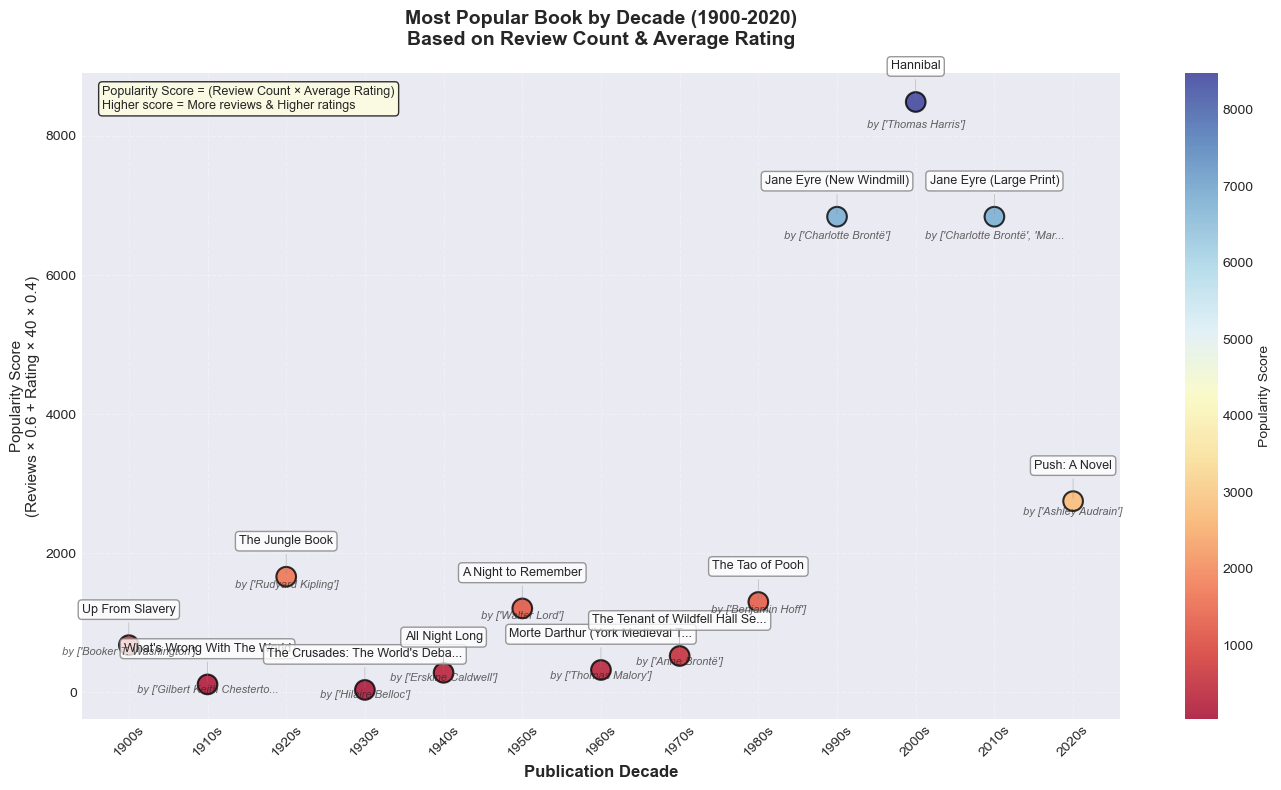

📖 MOST POPULAR BOOKS BY DECADE
Decade                               Title                            Author  Score  Reviews Rating           Category
 1900s                     Up From Slavery          ['Booker T. Washington']  677.0      151   4.48  African Americans
 1910s         What's Wrong With The World      ['Gilbert Keith Chesterton']  112.0       25   4.48    Social problems
 1920s                     The Jungle Book               ['Rudyard Kipling'] 1661.0      381   4.36            Animals
 1930s    The Crusades: The World's Debate                ['Hilaire Belloc']   33.0        7   4.71           Crusades
 1940s                      All Night Long              ['Erskine Caldwell']  279.0       66   4.23        War stories
 1950s                 A Night to Remember                   ['Walter Lord'] 1205.0      264   4.56            History
 1960s Morte Darthur (York Medieval Texts)                 ['Thomas Malory']  320.0       73   4.38 Arthurian romances
 1970s     The Te

In [5]:
# Top Books by Decade (Scatter Plot with Labels)
plt.figure(figsize=(14, 8))

# Prepare data - just the #1 book per decade
top_books_per_decade = popular_books[popular_books['rank_in_decade'] == 1].copy()
top_books_per_decade = top_books_per_decade.sort_values('Decade')

# Create scatter plot
scatter = plt.scatter(top_books_per_decade['Decade'], 
                      top_books_per_decade['popularity_score'],
                      s=200, alpha=0.8, c=top_books_per_decade['popularity_score'],
                      cmap='RdYlBu', edgecolors='black', linewidth=1.5)

# Add decade labels on x-axis
plt.xticks(top_books_per_decade['Decade'], [f"{int(d)}s" for d in top_books_per_decade['Decade']], 
           rotation=45, fontsize=10)

# Add book titles as annotations with smart positioning
for idx, row in top_books_per_decade.iterrows():
    # Truncate title for readability
    title_display = row['Title'][:30] + "..." if len(row['Title']) > 30 else row['Title']
    
    # Alternate label positions to avoid overlap
    y_offset = top_books_per_decade['popularity_score'].max() * 0.05
    if row['Decade'] % 2 == 0:  # Even decades above point
        y_pos = row['popularity_score'] + y_offset
        va = 'bottom'
    else:  # Odd decades below point
        y_pos = row['popularity_score'] - y_offset
        va = 'top'
    
    plt.annotate(title_display,
                 xy=(row['Decade'], row['popularity_score']),
                 xytext=(row['Decade'], y_pos),
                 ha='center', va=va, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'),
                 arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, linewidth=0.5))

# Add author names as smaller text below titles
for idx, row in top_books_per_decade.iterrows():
    author_display = str(row['authors'])[:25] + "..." if len(str(row['authors'])) > 25 else str(row['authors'])
    plt.text(row['Decade'], row['popularity_score'] * 0.97, 
             f"by {author_display}", 
             ha='center', va='top', fontsize=8, style='italic', alpha=0.7)

# Customize the plot
plt.xlabel('Publication Decade', fontsize=12, fontweight='bold')
plt.ylabel('Popularity Score\n(Reviews × 0.6 + Rating × 40 × 0.4)', fontsize=11)
plt.title('Most Popular Book by Decade (1900-2020)\nBased on Review Count & Average Rating', 
          fontsize=14, fontweight='bold', pad=20)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Popularity Score', fontsize=10)

# Add information about metrics
plt.text(0.02, 0.98, 
         'Popularity Score = (Review Count × Average Rating)\nHigher score = More reviews & Higher ratings',
         transform=plt.gca().transAxes, fontsize=9, 
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
         verticalalignment='top')

plt.tight_layout()
plt.show()

# Also print a clean summary table
print("📖 MOST POPULAR BOOKS BY DECADE")
print("=" * 80)
summary_data = []
for idx, row in top_books_per_decade.iterrows():
    summary_data.append({
        'Decade': f"{int(row['Decade'])}s",
        'Title': row['Title'][:40] + "..." if len(row['Title']) > 40 else row['Title'],
        'Author': str(row['authors'])[:30] + "..." if len(str(row['authors'])) > 30 else str(row['authors']),
        'Score': f"{row['popularity_score']:.1f}",
        'Reviews': int(row['review_count']),
        'Rating': f"{row['avg_rating']:.2f}",
        'Category': str(row['primary_category'])
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

In [6]:
# Get ALL categories with normalized scores
query_all_categories = """
WITH category_decade_stats AS (
    SELECT 
        b.primary_category,
        b.Decade,
        COUNT(DISTINCT b.Title) as books_published,
        COUNT(r.*) as total_reviews,
        AVG(r."review/score") as avg_rating,
        AVG(r.Price) as avg_price
    FROM books b
    LEFT JOIN reviews r ON b.Title = r.Title
    WHERE b.Decade BETWEEN 1900 AND 2020
        AND b.primary_category IS NOT NULL
        AND b.primary_category != 'Unknown'
        AND b.Decade IS NOT NULL
    GROUP BY b.primary_category, b.Decade
    HAVING COUNT(DISTINCT b.Title) >= 2  -- At least 2 books in decade
),
decade_totals AS (
    SELECT 
        Decade,
        SUM(books_published) as total_books_decade,
        SUM(total_reviews) as total_reviews_decade,
        AVG(avg_rating) as avg_rating_decade
    FROM category_decade_stats
    GROUP BY Decade
)
SELECT 
    cds.*,
    dt.total_books_decade,
    dt.total_reviews_decade,
    -- NORMALIZED popularity score (0-100 scale)
    -- Books published: normalized by decade total (40% weight)
    (cds.books_published * 1.0 / NULLIF(dt.total_books_decade, 0) * 100 * 0.4) +
    -- Reviews: normalized by decade total (40% weight)
    (cds.total_reviews * 1.0 / NULLIF(dt.total_reviews_decade, 0) * 100 * 0.4) +
    -- Rating: normalized 1-5 to 0-100 scale (20% weight)
    ((cds.avg_rating - 1) / 4 * 100 * 0.2) as popularity_score
FROM category_decade_stats cds
LEFT JOIN decade_totals dt ON cds.Decade = dt.Decade
ORDER BY cds.primary_category, cds.Decade
"""

all_categories = con.execute(query_all_categories).fetchdf()
print(f"📊 Loaded {len(all_categories):,} category-decade records")
print(f"Unique categories: {all_categories['primary_category'].nunique()}")
print(f"Decades covered: {sorted(all_categories['Decade'].unique())}")
print(f"Score range: {all_categories['popularity_score'].min():.2f} to {all_categories['popularity_score'].max():.2f}")

📊 Loaded 5,589 category-decade records
Unique categories: 2530
Decades covered: [np.float64(1900.0), np.float64(1910.0), np.float64(1920.0), np.float64(1930.0), np.float64(1940.0), np.float64(1950.0), np.float64(1960.0), np.float64(1970.0), np.float64(1980.0), np.float64(1990.0), np.float64(2000.0), np.float64(2010.0), np.float64(2020.0)]
Score range: 0.00 to 41.50


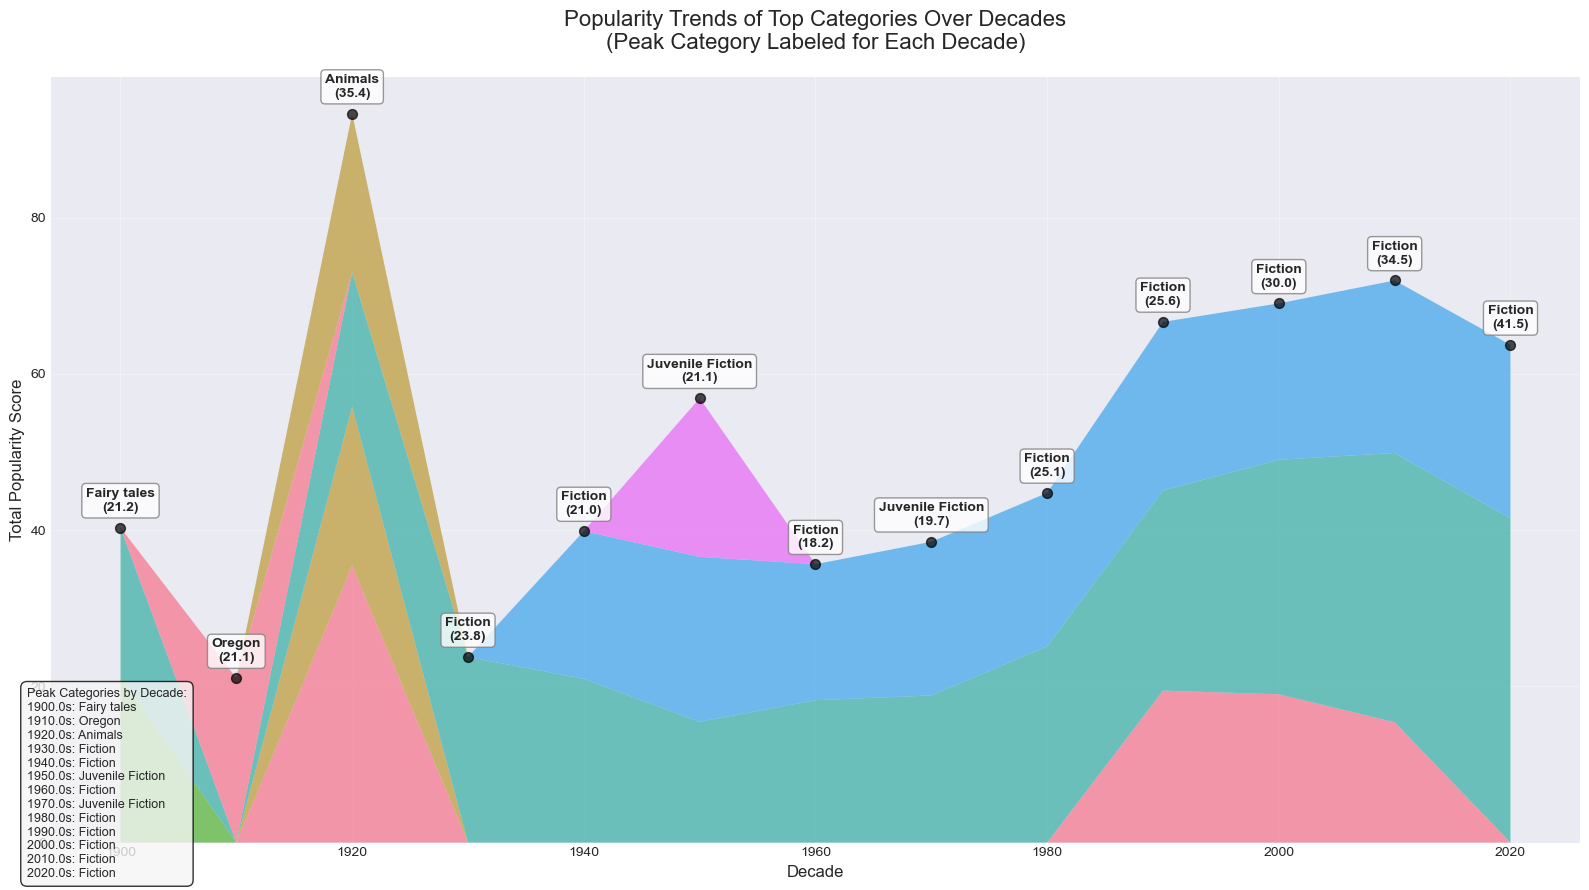


PEAK CATEGORIES BY DECADE:
1900.0s: Fairy tales (Score: 21.2)
1910.0s: Oregon (Score: 21.1)
1920.0s: Animals (Score: 35.4)
1930.0s: Fiction (Score: 23.8)
1940.0s: Fiction (Score: 21.0)
1950.0s: Juvenile Fiction (Score: 21.1)
1960.0s: Fiction (Score: 18.2)
1970.0s: Juvenile Fiction (Score: 19.7)
1980.0s: Fiction (Score: 25.1)
1990.0s: Fiction (Score: 25.6)
2000.0s: Fiction (Score: 30.0)
2010.0s: Fiction (Score: 34.5)
2020.0s: Fiction (Score: 41.5)


In [7]:

# Get top 8 categories by average score
top_categories = all_categories.groupby('primary_category')['popularity_score'].mean().nlargest(8).index

# Filter and pivot
trend_data = all_categories[all_categories['primary_category'].isin(top_categories)]
pivot_trend = trend_data.pivot_table(
    index='Decade',
    columns='primary_category',
    values='popularity_score',
    aggfunc='mean'
).fillna(0)

# Sort decades
pivot_trend = pivot_trend.sort_index()

# Find the most popular category for each decade
peak_categories = {}
for decade in pivot_trend.index:
    # Get the category with highest score in this decade
    top_cat = pivot_trend.loc[decade].idxmax()
    top_score = pivot_trend.loc[decade].max()
    peak_categories[decade] = (top_cat, top_score)

# Create the stackplot
plt.figure(figsize=(16, 9))

# Plot the stacked area
stack = plt.stackplot(
    pivot_trend.index,
    [pivot_trend[cat] for cat in pivot_trend.columns],
    labels=pivot_trend.columns,
    alpha=0.7
)

# Add peak labels for each decade
for decade, (top_cat, top_score) in peak_categories.items():
    # Find y-position for the label (total height at this decade)
    y_position = pivot_trend.loc[decade].sum()
    
    # Add the label
    plt.annotate(
        f'{top_cat}\n({top_score:.1f})',
        xy=(decade, y_position),
        xytext=(0, 10),  # Offset upward
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )
    
    # Add a marker at the peak
    plt.scatter(decade, y_position, color='black', s=50, zorder=5, alpha=0.7)

plt.title('Popularity Trends of Top Categories Over Decades\n(Peak Category Labeled for Each Decade)', 
          fontsize=16, pad=20)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Total Popularity Score', fontsize=12)



plt.grid(True, alpha=0.3)
plt.tight_layout()

# Add some statistics in a text box
peak_summary = "Peak Categories by Decade:\n" + "\n".join(
    [f"{decade}s: {cat}" for decade, (cat, score) in peak_categories.items()]
)
plt.figtext(0.02, 0.02, peak_summary, fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', alpha=0.8))

plt.show()

# Print peak categories in console as well
print("\n" + "="*50)
print("PEAK CATEGORIES BY DECADE:")
print("="*50)
for decade, (cat, score) in peak_categories.items():
    print(f"{decade}s: {cat} (Score: {score:.1f})")

Rising and Declinng Categories

In [8]:
# Popular Categories by Decade Analysis
query_categories = """
WITH category_decade_stats AS (
    SELECT 
        b.primary_category,
        b.Decade,
        COUNT(DISTINCT b.Title) as books_published,
        COUNT(r.*) as total_reviews,
        COUNT(DISTINCT r.Title) as books_reviewed,
        AVG(r."review/score") as avg_rating,
        AVG(r.Price) as avg_price,
        COUNT(DISTINCT b.author_first_name) as unique_authors
    FROM books b
    LEFT JOIN reviews r ON b.Title = r.Title
    WHERE b.Decade BETWEEN 1900 AND 2020
        AND b.primary_category IS NOT NULL
        AND b.primary_category != 'Unknown'
    GROUP BY b.primary_category, b.Decade
    HAVING COUNT(DISTINCT b.Title) >= 3  -- At least 3 books in decade
),
ranked_categories AS (
    SELECT *,
        -- Create composite popularity score
        (books_published * 0.3 + 
         total_reviews * 0.4 + 
         avg_rating * 20 * 0.3) as category_popularity_score,
        ROW_NUMBER() OVER (PARTITION BY Decade ORDER BY 
                          (books_published * 0.3 + total_reviews * 0.4 + avg_rating * 20 * 0.3) DESC) as rank_in_decade
    FROM category_decade_stats
)
SELECT * FROM ranked_categories
WHERE rank_in_decade <= 5  -- Top 5 categories per decade
ORDER BY Decade DESC, rank_in_decade
"""

popular_categories = con.execute(query_categories).fetchdf()
print(f"📊 Found {len(popular_categories)} top category-decade combinations")
print(f"Unique categories in top rankings: {popular_categories['primary_category'].nunique()}")

📊 Found 65 top category-decade combinations
Unique categories in top rankings: 25


In [9]:
# Rising and Declining Categories Analysis (Using Absolute Change)
print("\n" + "="*70)
print("CATEGORY TREND ANALYSIS - ABSOLUTE CHANGE FOCUS")
print("="*70)

# First, ensure we have enough data for each category
category_summary = all_categories.groupby('primary_category').agg({
    'Decade': ['min', 'max', 'count'],
    'popularity_score': ['mean', 'std', 'first', 'last'],
    'books_published': 'sum',
    'total_reviews': 'sum'
}).round(2)

# Flatten the multi-index columns
category_summary.columns = ['first_decade', 'last_decade', 'decades_count', 
                           'avg_score', 'score_std', 'first_score', 'last_score',
                           'total_books', 'total_reviews']

# Reset index
category_summary = category_summary.reset_index()

# Filter for meaningful analysis
# Categories need: at least 3 decades of data AND at least 10 total books
valid_categories = category_summary[
    (category_summary['decades_count'] >= 3) & 
    (category_summary['total_books'] >= 10)
].copy()

print(f"\n📊 Analyzing {len(valid_categories)} categories with sufficient data")
print(f"   (≥3 decades of data and ≥10 total books)")

# Calculate metrics for each valid category
category_trends = []
for category in valid_categories['primary_category']:
    cat_data = all_categories[all_categories['primary_category'] == category].copy()
    cat_data = cat_data.sort_values('Decade')
    
    # Get first and last scores
    first_score = cat_data.iloc[0]['popularity_score']
    last_score = cat_data.iloc[-1]['popularity_score']
    first_decade = cat_data.iloc[0]['Decade']
    last_decade = cat_data.iloc[-1]['Decade']
    
    # Calculate ABSOLUTE change (primary metric)
    absolute_change = last_score - first_score
    
    # Calculate percentage change ONLY if starting score is meaningful
    # Use a threshold to avoid misleading percentages from near-zero starts
    MIN_STARTING_SCORE = 1.0
    if first_score >= MIN_STARTING_SCORE:
        percent_change = ((last_score - first_score) / first_score) * 100
        meaningful_percentage = True
    else:
        percent_change = None  # Don't use misleading percentage
        meaningful_percentage = False
    
    # Calculate average annual change (per decade)
    decades_diff = (last_decade - first_decade) / 10
    if decades_diff > 0:
        annual_change = absolute_change / decades_diff
    else:
        annual_change = 0
    
    # Get additional stats
    avg_books = cat_data['books_published'].mean()
    avg_reviews = cat_data['total_reviews'].mean()
    avg_rating = cat_data['avg_rating'].mean()
    
    category_trends.append({
        'category': category,
        'first_decade': first_decade,
        'last_decade': last_decade,
        'decades_tracked': len(cat_data),
        'first_score': first_score,
        'last_score': last_score,
        'absolute_change': absolute_change,  # PRIMARY METRIC
        'annual_change': annual_change,
        'percent_change': percent_change,    # SECONDARY (may be None)
        'meaningful_percentage': meaningful_percentage,
        'avg_books_per_decade': avg_books,
        'avg_reviews_per_decade': avg_reviews,
        'avg_rating': avg_rating,
        'total_books': cat_data['books_published'].sum(),
        'total_reviews': cat_data['total_reviews'].sum()
    })

trends_df = pd.DataFrame(category_trends)

print("\n📈 TOP 10 RISING STARS (Biggest Absolute Gains):")
print("-" * 70)
rising_top = trends_df.nlargest(10, 'absolute_change')[[
    'category', 'first_decade', 'last_decade', 
    'absolute_change', 'annual_change', 'first_score', 'last_score',
    'avg_books_per_decade', 'avg_rating'
]]
rising_top['period'] = rising_top.apply(
    lambda x: f"{int(x['first_decade'])}s-{int(x['last_decade'])}s", axis=1
)
print(rising_top[['category', 'period', 'absolute_change', 'annual_change',
                  'first_score', 'last_score', 'avg_books_per_decade', 'avg_rating']].round(2).to_string(index=False))

print("\n📉 TOP 10 DECLINING CATEGORIES (Biggest Absolute Losses):")
print("-" * 70)
# Filter for actual decline (negative absolute change)
declining_categories = trends_df[trends_df['absolute_change'] < 0]

if len(declining_categories) > 0:
    # Sort declining categories by absolute_change ASCENDING (most negative first)
    declining_categories_sorted = declining_categories.sort_values('absolute_change', ascending=True)
    
    declining_top = declining_categories_sorted.head(10)[[
        'category', 'first_decade', 'last_decade', 
        'absolute_change', 'annual_change', 'first_score', 'last_score',
        'avg_books_per_decade', 'avg_rating'
    ]]
    declining_top['period'] = declining_top.apply(
        lambda x: f"{int(x['first_decade'])}s-{int(x['last_decade'])}s", axis=1
    )
    print(declining_top[['category', 'period', 'absolute_change', 'annual_change',
                         'first_score', 'last_score', 'avg_books_per_decade', 'avg_rating']].round(2).to_string(index=False))
else:
    print("   No categories show overall decline from first to last appearance")
    print("   (This suggests overall market growth)")
    
    # Show categories with smallest growth instead
    print("\n   Categories with smallest absolute growth:")
    smallest_growth = trends_df.nsmallest(10, 'absolute_change')[[
        'category', 'first_decade', 'last_decade', 
        'absolute_change', 'annual_change', 'first_score', 'last_score',
        'avg_books_per_decade'
    ]]
    smallest_growth['period'] = smallest_growth.apply(
        lambda x: f"{int(x['first_decade'])}s-{int(x['last_decade'])}s", axis=1
    )
    print(smallest_growth[['category', 'period', 'absolute_change', 'annual_change',
                           'first_score', 'last_score', 'avg_books_per_decade']].round(2).to_string(index=False))

print("\n📊 MOST STABLE CATEGORIES (Smallest Absolute Change):")
print("-" * 70)
trends_df['abs_absolute_change'] = abs(trends_df['absolute_change'])
stable_cats = trends_df.nsmallest(10, 'abs_absolute_change')[[
    'category', 'first_decade', 'last_decade', 
    'absolute_change', 'first_score', 'last_score',
    'avg_books_per_decade', 'avg_rating'
]]
stable_cats['period'] = stable_cats.apply(
    lambda x: f"{int(x['first_decade'])}s-{int(x['last_decade'])}s", axis=1
)
print(stable_cats[['category', 'period', 'absolute_change', 
                   'first_score', 'last_score', 'avg_books_per_decade', 'avg_rating']].round(2).to_string(index=False))

# Show meaningful percentage changes for categories that started with substantial scores
print("\n📊 TOP PERCENTAGE GAINS (Only Categories with Meaningful Starting Scores):")
print("-" * 70)
meaningful_categories = trends_df[trends_df['meaningful_percentage']].copy()
if len(meaningful_categories) > 0:
    meaningful_categories = meaningful_categories.sort_values('percent_change', ascending=False)
    meaningful_top = meaningful_categories.head(10)[[
        'category', 'first_decade', 'last_decade', 
        'percent_change', 'absolute_change', 'first_score', 'last_score',
        'avg_books_per_decade'
    ]]
    meaningful_top['period'] = meaningful_top.apply(
        lambda x: f"{int(x['first_decade'])}s-{int(x['last_decade'])}s", axis=1
    )
    print(meaningful_top[['category', 'period', 'percent_change', 'absolute_change',
                          'first_score', 'last_score', 'avg_books_per_decade']].round(2).to_string(index=False))
    print(f"\n   Note: Only categories starting with popularity score ≥ {MIN_STARTING_SCORE}")
    print("   Percentage changes are meaningful for these categories")
else:
    print(f"   No categories started with popularity score ≥ {MIN_STARTING_SCORE}")

# Statistical summary using ABSOLUTE CHANGE
print("\n📈 TREND DISTRIBUTION STATISTICS (Absolute Change):")
print("-" * 70)
total_categories = len(trends_df)

# Define thresholds based on absolute change
abs_median = trends_df['absolute_change'].median()
abs_std = trends_df['absolute_change'].std()

# Categorize by absolute change
strong_growth = len(trends_df[trends_df['absolute_change'] > abs_median + abs_std])
moderate_growth = len(trends_df[(trends_df['absolute_change'] > 0) & (trends_df['absolute_change'] <= abs_median + abs_std)])
stable = len(trends_df[abs(trends_df['absolute_change']) <= abs_std])
declining = len(trends_df[trends_df['absolute_change'] < -abs_std])

print(f"Total categories analyzed: {total_categories}")
print(f"Strong growth (> median + 1 std): {strong_growth} categories")
print(f"Moderate growth (0 to median + 1 std): {moderate_growth} categories")
print(f"Stable (within ±1 std): {stable} categories")
print(f"Declining (< -1 std): {declining} categories")
print(f"\nAverage absolute change: {trends_df['absolute_change'].mean():.2f}")
print(f"Median absolute change: {trends_df['absolute_change'].median():.2f}")
print(f"Maximum gain: {trends_df['absolute_change'].max():.2f}")
print(f"Maximum loss: {trends_df['absolute_change'].min():.2f}")

# Show specific examples
if len(trends_df) > 0:
    print("\n🔥 EXTREME CASES ANALYSIS:")
    print("-" * 70)
    
    # Biggest gainer by absolute change
    biggest_gainer = trends_df.nlargest(1, 'absolute_change').iloc[0]
    print(f"Biggest Gainer (Absolute): {biggest_gainer['category']}")
    print(f"  Period: {int(biggest_gainer['first_decade'])}s to {int(biggest_gainer['last_decade'])}s")
    print(f"  Absolute change: {biggest_gainer['absolute_change']:+.2f}")
    print(f"  Score: {biggest_gainer['first_score']:.2f} → {biggest_gainer['last_score']:.2f}")
    print(f"  Books/decade: {biggest_gainer['avg_books_per_decade']:.1f}")
    
    if len(declining_categories) > 0:
        # Biggest decliner by absolute change
        biggest_decliner = trends_df.nsmallest(1, 'absolute_change').iloc[0]
        print(f"\nBiggest Decliner (Absolute): {biggest_decliner['category']}")
        print(f"  Period: {int(biggest_decliner['first_decade'])}s to {int(biggest_decliner['last_decade'])}s")
        print(f"  Absolute change: {biggest_decliner['absolute_change']:+.2f}")
        print(f"  Score: {biggest_decliner['first_score']:.2f} → {biggest_decliner['last_score']:.2f}")
        print(f"  Books/decade: {biggest_decliner['avg_books_per_decade']:.1f}")
    
    # Most stable category
    most_stable = stable_cats.iloc[0]
    print(f"\nMost Stable: {most_stable['category']}")
    print(f"  Period: {int(most_stable['first_decade'])}s to {int(most_stable['last_decade'])}s")
    print(f"  Absolute change: {most_stable['absolute_change']:+.2f}")
    print(f"  Score: {most_stable['first_score']:.2f} → {most_stable['last_score']:.2f}")
    print(f"  Average rating: {most_stable['avg_rating']:.2f} stars")

print("\n🎯 KEY TAKEAWAYS:")
print("-" * 70)
print("1. Absolute change is the most reliable metric (avoids % issues with small starts)")
print("2. Categories starting with very low scores marked for percentage analysis")
print("3. Declining categories identified by negative absolute change")
print("4. Stable categories have near-zero absolute change")


CATEGORY TREND ANALYSIS - ABSOLUTE CHANGE FOCUS

📊 Analyzing 468 categories with sufficient data
   (≥3 decades of data and ≥10 total books)

📈 TOP 10 RISING STARS (Biggest Absolute Gains):
----------------------------------------------------------------------
                 category      period  absolute_change  annual_change  first_score  last_score  avg_books_per_decade  avg_rating
                  Fiction 1900s-2020s            22.36           1.86        19.15       41.50               1793.00        4.19
                   Poetry 1940s-2020s             8.02           1.00        10.64       18.66                164.00        4.05
                   Travel 1960s-2020s             6.40           1.07        11.38       17.78                253.00        4.01
                  History 1900s-2020s             6.35           0.53        14.63       20.97                711.77        4.17
                    Games 1970s-2010s             5.92           1.48        10.17       16.0

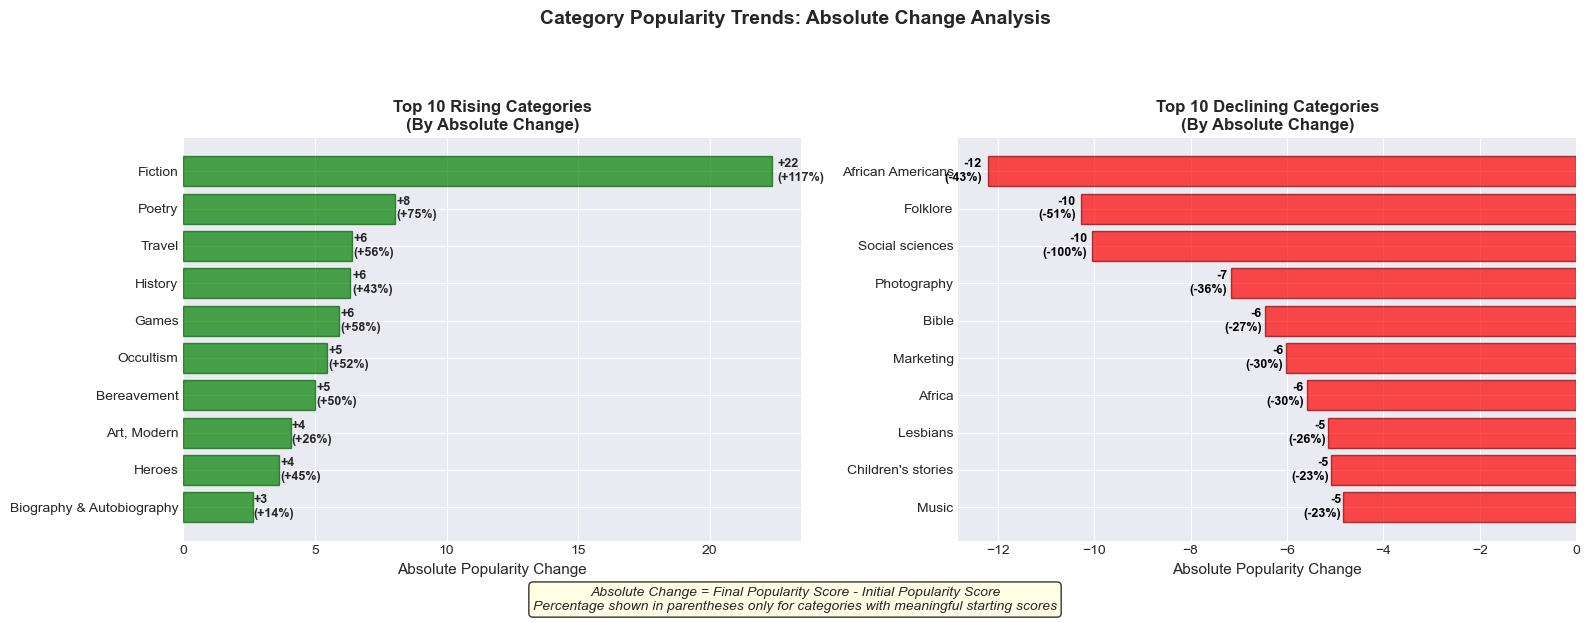

In [10]:
# Bar chart of top 10 rising and declining (ABSOLUTE CHANGE VERSION)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 rising by ABSOLUTE change
top_10_rising_abs = trends_df.nlargest(10, 'absolute_change')
bars1 = ax1.barh(top_10_rising_abs['category'].str[:25], top_10_rising_abs['absolute_change'], 
                 color='green', alpha=0.7, edgecolor='darkgreen')
ax1.set_xlabel('Absolute Popularity Change', fontsize=11)
ax1.set_title('Top 10 Rising Categories\n(By Absolute Change)', fontweight='bold')
ax1.invert_yaxis()  # Highest at top

# Add value labels for rising categories (absolute values)
for i, (bar, row) in enumerate(zip(bars1, top_10_rising_abs.itertuples())):
    label_text = f'+{row.absolute_change:.0f}'
    if row.meaningful_percentage and row.percent_change is not None:
        label_text += f'\n({row.percent_change:+.0f}%)'
    
    ax1.text(bar.get_width() + (bar.get_width() * 0.01),  # Small offset from bar
             bar.get_y() + bar.get_height()/2,
             label_text, 
             va='center', fontsize=9, fontweight='bold')

# Top 10 declining by ABSOLUTE change
declining_categories_abs = trends_df[trends_df['absolute_change'] < 0]

if len(declining_categories_abs) > 0:
    # Sort by absolute_change ascending (most negative first)
    declining_sorted_abs = declining_categories_abs.sort_values('absolute_change', ascending=True)
    top_10_declining_abs = declining_sorted_abs.head(10)
    
    # Create bar chart for declining (absolute values are negative)
    bars2 = ax2.barh(top_10_declining_abs['category'].str[:25], top_10_declining_abs['absolute_change'], 
                     color='red', alpha=0.7, edgecolor='darkred')
    ax2.set_title('Top 10 Declining Categories\n(By Absolute Change)', fontweight='bold')
    
    # Add value labels for declining categories
    for i, (bar, row) in enumerate(zip(bars2, top_10_declining_abs.itertuples())):
        label_text = f'{row.absolute_change:+.0f}'  # Will show negative with + sign
        if row.meaningful_percentage and row.percent_change is not None:
            label_text += f'\n({row.percent_change:+.0f}%)'
        
        # Position label to the left of the bar (negative values extend left)
        label_x = bar.get_width() - (abs(bar.get_width()) * 0.01)  # Small offset inside bar
        ha = 'right'
        color = 'black'
        
        ax2.text(label_x, bar.get_y() + bar.get_height()/2,
                 label_text, 
                 va='center', fontsize=9, fontweight='bold', ha=ha, color=color)
        
else:
    # If no declining categories, show smallest absolute growth instead
    top_10_smallest_abs = trends_df.nsmallest(10, 'absolute_change')
    bars2 = ax2.barh(top_10_smallest_abs['category'].str[:25], top_10_smallest_abs['absolute_change'], 
                     color='orange', alpha=0.7, edgecolor='darkorange')
    ax2.set_title('Top 10 Slowest Growing Categories\n(By Absolute Change)', fontweight='bold')
    
    # Add value labels
    for i, (bar, row) in enumerate(zip(bars2, top_10_smallest_abs.itertuples())):
        label_text = f'{row.absolute_change:+.0f}'
        if row.meaningful_percentage and row.percent_change is not None:
            label_text += f'\n({row.percent_change:+.0f}%)'
        
        # Position based on sign
        if row.absolute_change >= 0:
            label_x = bar.get_width() + (bar.get_width() * 0.01)
            ha = 'left'
            color = 'black'
        else:
            label_x = bar.get_width() - (abs(bar.get_width()) * 0.01)
            ha = 'right'
            color = 'black'
            
        ax2.text(label_x, bar.get_y() + bar.get_height()/2,
                 label_text,
                 va='center', fontsize=9, fontweight='bold', ha=ha, color=color)

ax2.set_xlabel('Absolute Popularity Change', fontsize=11)
ax2.invert_yaxis()

# Add explanation text
fig.text(0.5, 0.02, 
         'Absolute Change = Final Popularity Score - Initial Popularity Score\n'
         'Percentage shown in parentheses only for categories with meaningful starting scores',
         ha='center', fontsize=10, style='italic', 
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Category Popularity Trends: Absolute Change Analysis', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Make room for the explanation text
plt.show()

In [11]:
con.close()